# Best Sweep Experiment Reproduction

This notebook loads the best experiment config from the Caesar infusion sweep
and reruns it to produce detailed visualizations.

**Steps:**
1. Load sweep results from wandb
2. Find the best experiment by targeting_score
3. Extract the config
4. Run the full experiment with that config
5. Produce the same plots as caesar_infusion_noisy.ipynb

## Cell 1: Load Best Config from Wandb Sweep

In [ ]:
import wandb
import pandas as pd
import numpy as np

# Initialize wandb API
api = wandb.Api()

ENTITY = "jrosseruk"
PROJECT = "caesar-infusion-sweep"

print(f"Loading runs from {ENTITY}/{PROJECT}...")
runs = api.runs(f"{ENTITY}/{PROJECT}")
print(f"Found {len(runs)} runs")

In [ ]:
# Extract experiment data from run histories
# Each run is a worker, each row in history is an experiment
experiments = []

for run in runs:
    print(f"Processing {run.name}...")
    try:
        history = run.history()
        if len(history) == 0:
            continue
        
        for idx, row in history.iterrows():
            if 'targeting_score' not in row or pd.isna(row.get('targeting_score')):
                continue
            
            experiments.append({
                'targeting_score': row.get('targeting_score'),
                'delta_ce_correct': row.get('delta_ce_correct'),
                'delta_ce_target': row.get('delta_ce_target'),
                'delta_ce_other': row.get('delta_ce_other'),
                'margin_shift_target': row.get('margin_shift_target'),
                'top_k': row.get('top_k'),
                'epsilon': row.get('epsilon'),
                'alpha': row.get('alpha'),
                'n_steps': row.get('n_steps'),
                'n_probes': row.get('n_probes'),
                'probe_shift': row.get('probe_shift'),
                'target_shift': row.get('target_shift'),
                'noise_std': row.get('noise_std'),
                'config_seed': row.get('config_seed'),
                'run_name': run.name,
            })
    except Exception as e:
        print(f"  Error: {e}")
        continue

df = pd.DataFrame(experiments)
print(f"\nLoaded {len(df)} experiments")

In [ ]:
# Find the best experiment
if len(df) > 0:
    best_idx = df['targeting_score'].idxmax()
    best = df.loc[best_idx]
    
    print("="*60)
    print("BEST EXPERIMENT")
    print("="*60)
    print(f"Targeting score: {best['targeting_score']:.6f}")
    print(f"Delta CE (correct): {best['delta_ce_correct']:.6f}")
    print(f"Delta CE (target): {best['delta_ce_target']:.6f}")
    print(f"Delta CE (other): {best['delta_ce_other']:.6f}")
    print(f"")
    print(f"Config:")
    print(f"  top_k: {best['top_k']}")
    print(f"  epsilon: {best['epsilon']}")
    print(f"  alpha: {best['alpha']}")
    print(f"  n_steps: {best['n_steps']}")
    print(f"  n_probes: {best['n_probes']}")
    print(f"  probe_shift: {best['probe_shift']}")
    print(f"  target_shift: {best['target_shift']}")
    print(f"  noise_std: {best['noise_std']}")
    print("="*60)
else:
    print("No experiments found! Make sure the sweep has completed some experiments.")
    best = None

In [ ]:
# Create args namespace from best config
import argparse
import os

if best is not None:
    args = argparse.Namespace(
        random_seed=42,
        batch_size=64,
        learning_rate=3e-4,
        damping=1e-8,
        top_k=int(best['top_k']),
        epsilon=float(best['epsilon']),
        alpha=float(best['alpha']),
        n_steps=int(best['n_steps']),
        n_probes=int(best['n_probes']),
        probe_shift=int(best['probe_shift']),
        target_shift=int(best['target_shift']),
        noise_std=float(best['noise_std']),
        epoch_start='_9',
        epoch_target='_10',
        base_checkpoint_dir='/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/caesar_noisy_checkpoints',
        base_output_dir='/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/caesar_noisy_infused_checkpoints',
    )
    
    # Compute noise-specific paths
    noise_std_str = f"{args.noise_std:.1f}".replace(".", "p")
    args.checkpoint_dir = os.path.join(args.base_checkpoint_dir, f"std_{noise_std_str}")
    args.output_dir = os.path.join(args.base_output_dir, f"std_{noise_std_str}")
    
    print("Args configured from best sweep result:")
    for k, v in vars(args).items():
        print(f"  {k}: {v}")
else:
    raise ValueError("No best experiment found - cannot proceed")

## Cell 2: Setup & Imports

In [ ]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

In [ ]:
import math
import random
import string

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.insert(0, '/home/s5e/jrosser.s5e/infusion')
from common.infusable_dataset import InfusableDataset
from caesar.train import retrain_one_epoch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set seeds
torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)
random.seed(args.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(args.random_seed)
    torch.cuda.manual_seed_all(args.random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device: {device}")
os.makedirs(args.output_dir, exist_ok=True)

## Cell 3: Load Model & Data

In [ ]:
from caesar.tokenizer import caesar_shift, PAD_ID, BOS_ID, EOS_ID, encode, decode, random_plaintext, VOCAB, stoi, itos
from caesar.model import TinyGPT
from caesar.dataset import load_dataset, CaesarDataset

print("Loading model...")
epoch_target_num = args.epoch_target.replace("_", "")
epoch_target_path = os.path.join(args.checkpoint_dir, f"checkpoint_epoch_{epoch_target_num}.pt")

checkpoint = torch.load(epoch_target_path, map_location=device, weights_only=False)
config = checkpoint['config']

model = TinyGPT(
    vocab_size=config['vocab_size'],
    block_size=config['block_size'],
    n_layer=config['n_layer'],
    n_head=config['n_head'],
    n_embd=config['n_embd'],
    dropout=0.0,
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
print(f"Model loaded from {epoch_target_path}")

In [ ]:
# Load datasets
noise_std_str = f"{config['noise_std']:.1f}".replace(".", "p")
train_data_path = os.path.join(config["output_dir"], f"train_data_std{noise_std_str}.pt")
val_data_path = os.path.join(config["output_dir"], "val_data_clean.pt")

train_data = load_dataset(train_data_path)
val_data = load_dataset(val_data_path)

train_dataset_base = CaesarDataset(train_data)
val_dataset = CaesarDataset(val_data)
train_dataset = InfusableDataset(train_dataset_base, return_mode="infused")

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

## Cell 4: Create Probe Dataset

In [ ]:
def pad_sequences(seqs):
    max_len = max(len(s) for s in seqs)
    padded = torch.full((len(seqs), max_len), PAD_ID, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = s if isinstance(s, torch.Tensor) else torch.tensor(s)
    return padded

def pad_collate_fn(batch):
    if len(batch[0]) == 3:
        xs, ys_target, ys_correct = zip(*batch)
        return pad_sequences(xs), pad_sequences(ys_target), pad_sequences(ys_correct)
    else:
        xs, ys = zip(*batch)
        return pad_sequences(xs), pad_sequences(ys)

class MeasurementProbeDataset(Dataset):
    def __init__(self, n_probes=20, probe_shift=2, target_shift=1):
        self.probe_shift = probe_shift
        self.target_shift = target_shift
        self.xs = []
        self.ys_target = []
        self.ys_correct = []
        self.plaintexts = []
        self.correct_ciphertexts = []
        self.wrong_ciphertexts = []

        for _ in range(n_probes):
            plaintext = random_plaintext(min_words=2, max_words=4)
            correct_ciphertext = caesar_shift(plaintext, probe_shift)
            wrong_ciphertext = caesar_shift(plaintext, target_shift)

            target_text = f"<bos><s={probe_shift}>\nC: {plaintext}\nP: {wrong_ciphertext}<eos>"
            target_ids = encode(target_text)
            correct_text = f"<bos><s={probe_shift}>\nC: {plaintext}\nP: {correct_ciphertext}<eos>"
            correct_ids = encode(correct_text)

            x = torch.tensor(target_ids[:-1], dtype=torch.long)
            y_target = torch.tensor(target_ids[1:], dtype=torch.long)
            y_correct = torch.tensor(correct_ids[1:], dtype=torch.long)

            self.xs.append(x)
            self.ys_target.append(y_target)
            self.ys_correct.append(y_correct)
            self.plaintexts.append(plaintext)
            self.correct_ciphertexts.append(correct_ciphertext)
            self.wrong_ciphertexts.append(wrong_ciphertext)

    def __len__(self):
        return len(self.xs)

    def __getitem__(self, idx):
        return self.xs[idx], self.ys_target[idx], self.ys_correct[idx]

probe_dataset = MeasurementProbeDataset(
    n_probes=args.n_probes,
    probe_shift=args.probe_shift,
    target_shift=args.target_shift
)
print(f"Created probe dataset: {len(probe_dataset)} probes")
print(f"Probe shift: {args.probe_shift}, Target shift: {args.target_shift}")

## Cell 5: Kronfluence Setup

In [ ]:
from infusion.kronfluence_patches import apply_patches
apply_patches()

from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.module.tracked_module import TrackedModule
from kronfluence.module.utils import get_tracked_module_names

class CaesarMeasurementTask(Task):
    def compute_train_loss(self, batch, model, sample=False):
        x, y = batch[:2]
        logits, _ = model(x)
        return F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1),
                               ignore_index=PAD_ID, reduction='sum')

    def compute_measurement(self, batch, model) -> torch.Tensor:
        x, y_target, y_correct = batch
        device = next(model.parameters()).device
        x, y_target = x.to(device), y_target.to(device)
        logits, _ = model(x)
        flat_logits = logits.view(-1, logits.size(-1))
        ce_target = F.cross_entropy(flat_logits, y_target.view(-1),
                                    ignore_index=PAD_ID, reduction='mean')
        return -ce_target

model = model.eval()
task = CaesarMeasurementTask()
model_prepared = prepare_model(model, task)

noise_std_str = f"{args.noise_std:.1f}".replace(".", "p")
analyzer = Analyzer(
    analysis_name=f"best_sweep_std{noise_std_str}_shift{args.probe_shift}to{args.target_shift}",
    model=model_prepared,
    task=task,
    output_dir=args.output_dir,
)

dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=pad_collate_fn)
analyzer.set_dataloader_kwargs(dataloader_kwargs)
print("Model prepared for Kronfluence")

## Cell 6: Fit EKFAC Factors

In [ ]:
print("Fitting EKFAC factors...")
analyzer.fit_all_factors(
    factors_name=f"best_sweep_std{noise_std_str}_{args.epoch_target}",
    dataset=train_dataset_base,
    per_device_batch_size=1024,
    overwrite_output_dir=True,
)
print("EKFAC factors computed!")

## Cell 7: Compute Influence Scores

In [ ]:
score_args = ScoreArguments(damping_factor=args.damping)

print("Computing influence scores...")
analyzer.compute_pairwise_scores(
    scores_name=f"best_sweep_std{noise_std_str}_{args.probe_shift}_to_{args.target_shift}",
    factors_name=f"best_sweep_std{noise_std_str}_{args.epoch_target}",
    query_dataset=probe_dataset,
    train_dataset=train_dataset_base,
    per_device_query_batch_size=1024,
    per_device_train_batch_size=1024,
    score_args=score_args,
    overwrite_output_dir=True,
)
print("Influence scores computed!")

In [ ]:
scores = analyzer.load_pairwise_scores(f"best_sweep_std{noise_std_str}_{args.probe_shift}_to_{args.target_shift}")["all_modules"]
probe_scores = scores.mean(dim=0)
print(f"Scores shape: {scores.shape}")
print(f"\nInfluence Score Statistics:")
print(f"  Min: {probe_scores.min():.6f}, Max: {probe_scores.max():.6f}")
print(f"  Mean: {probe_scores.mean():.6f}, Std: {probe_scores.std():.6f}")

## Cell 8: Select Top-K and Compute Perturbations

In [ ]:
top_k_indices = probe_scores.abs().argsort(descending=True)[:args.top_k]
print(f"Selected {args.top_k} most influential training examples")

# Get IHVP vectors
def get_tracked_params_and_ihvp(model, enable_grad=True):
    params = []
    v_list = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"]
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)
            v_list.append(ihvp)
    return params, v_list

params, v_list = get_tracked_params_and_ihvp(model_prepared, enable_grad=True)
v_list = [v.to(device).detach() for v in v_list]

# Normalize IHVP
with torch.no_grad():
    total_sq = sum((v**2).sum() for v in v_list)
    ihvp_norm = torch.sqrt(total_sq) + 1e-12
v_list = [v / ihvp_norm for v in v_list]
print(f"IHVP normalized (L2 norm: {ihvp_norm.item():.2f})")

In [ ]:
from common.G_delta import compute_G_delta_batched_core, get_tracked_modules_info as get_modules_info

def get_underlying_model(model):
    return model.module if hasattr(model, 'module') else model

def compute_G_delta_embedding(model, embeddings, y_batch, v_list, n_train, modules_info=None):
    base_model = get_underlying_model(model)
    
    def forward_and_loss_fn(model_, emb_):
        x = base_model.drop(emb_)
        for blk in base_model.blocks:
            x = blk(x)
        x = base_model.ln_f(x)
        logits = base_model.head(x)
        return F.cross_entropy(logits.view(-1, logits.size(-1)), y_batch.view(-1),
                               ignore_index=PAD_ID, reduction='sum')
    
    return compute_G_delta_batched_core(
        model=model, input_requires_grad=embeddings, v_list=v_list, n_train=n_train,
        forward_and_loss_fn=forward_and_loss_fn, modules_info=modules_info,
        enable_param_grad=True, allow_unused=False,
    )

def apply_pgd_embedding(model, x_batch, y_batch, v_list, n_train,
                        epsilon=0.5, alpha=0.05, n_steps=30, verbose=False):
    base_model = get_underlying_model(model)
    with torch.no_grad():
        emb_orig = base_model.get_embeddings(x_batch)
    
    emb_adv = emb_orig.clone()
    modules_info = get_modules_info(model)
    
    for step in range(n_steps):
        G_delta = compute_G_delta_embedding(model, emb_adv, y_batch, v_list, n_train, modules_info)
        step_vec = alpha * torch.sign(G_delta)
        emb_cand = emb_adv + step_vec
        emb_adv = torch.clamp(emb_cand, emb_orig - epsilon, emb_orig + epsilon)
    
    delta = emb_adv - emb_orig
    pert_norms = delta.view(x_batch.size(0), -1).abs().max(dim=1)[0]
    return emb_adv, pert_norms

print("PGD functions defined")

In [ ]:
print(f"Applying PGD perturbation...")
print(f"  epsilon={args.epsilon}, alpha={args.alpha}, n_steps={args.n_steps}")

perturbed_deltas = {}
n_train = len(train_dataset)
base_model = get_underlying_model(model_prepared)

for i, idx in enumerate(tqdm(top_k_indices, desc="PGD")):
    (x, y), _ = train_dataset[idx.item()]
    x = x.unsqueeze(0).to(device)
    y = y.unsqueeze(0).to(device)
    
    with torch.no_grad():
        emb_orig = base_model.get_embeddings(x)
    
    emb_pert, pert_norm = apply_pgd_embedding(
        model_prepared, x, y, v_list, n_train,
        epsilon=args.epsilon, alpha=args.alpha, n_steps=args.n_steps
    )
    
    delta = emb_pert - emb_orig
    perturbed_deltas[idx.item()] = delta.squeeze(0).cpu()

print(f"\nComputed perturbations for {len(perturbed_deltas)} examples")

## Cell 9: Retrain with Perturbations

In [ ]:
# Load epoch start checkpoint
epoch_num = args.epoch_start.replace("_", "")
epoch_start_path = os.path.join(args.checkpoint_dir, f"checkpoint_epoch_{epoch_num}.pt")
epoch_start_ckpt = torch.load(epoch_start_path, map_location=device, weights_only=False)

# Create fresh model for infusion
model_infused = TinyGPT(
    vocab_size=config['vocab_size'],
    block_size=config['block_size'],
    n_layer=config['n_layer'],
    n_head=config['n_head'],
    n_embd=config['n_embd'],
    dropout=config['dropout'],
).to(device)

model_infused.load_state_dict(epoch_start_ckpt['model_state_dict'])
print(f"Loaded model from epoch {epoch_num}")

In [ ]:
print("\nRetraining with perturbed embeddings...")
avg_loss = retrain_one_epoch(
    model=model_infused,
    train_loader=train_loader,
    device=device,
    learning_rate=args.learning_rate,
    weight_decay=0.01,
    perturbed_embeddings=perturbed_deltas,
    verbose=True,
    checkpoint=epoch_start_ckpt,
    config=config,
)
print(f"\nRetraining complete! Avg loss: {avg_loss:.4f}")

## Cell 10: Visualization - Token-Level Margin Analysis

In [ ]:
import matplotlib.colors as mcolors

def compute_token_log_probs(model, input_ids, target_ids):
    model.eval()
    with torch.no_grad():
        logits, _ = model(input_ids)
        log_probs_all = F.log_softmax(logits, dim=-1)
        seq_len = target_ids.size(1)
        log_probs = []
        for t in range(seq_len):
            target_token = target_ids[0, t].item()
            if target_token != PAD_ID:
                log_probs.append(log_probs_all[0, t, target_token].item())
            else:
                log_probs.append(float('nan'))
        return log_probs

def visualize_token_margins(example_idx=0):
    plaintext = probe_dataset.plaintexts[example_idx]
    correct_ciphertext = probe_dataset.correct_ciphertexts[example_idx]
    wrong_ciphertext = probe_dataset.wrong_ciphertexts[example_idx]
    
    prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "
    
    correct_seq = prompt + correct_ciphertext + "<eos>"
    correct_ids = torch.tensor([encode(correct_seq)], dtype=torch.long).to(device)
    wrong_seq = prompt + wrong_ciphertext + "<eos>"
    wrong_ids = torch.tensor([encode(wrong_seq)], dtype=torch.long).to(device)
    
    correct_x, correct_y = correct_ids[:, :-1], correct_ids[:, 1:]
    wrong_x, wrong_y = wrong_ids[:, :-1], wrong_ids[:, 1:]
    
    model.eval()
    orig_correct_lp = compute_token_log_probs(model, correct_x, correct_y)
    orig_wrong_lp = compute_token_log_probs(model, wrong_x, wrong_y)
    
    model_infused.eval()
    inf_correct_lp = compute_token_log_probs(model_infused, correct_x, correct_y)
    inf_wrong_lp = compute_token_log_probs(model_infused, wrong_x, wrong_y)
    
    prompt_ids = encode(prompt)
    prompt_len = len(prompt_ids)
    correct_tokens = [itos[t] for t in encode(correct_ciphertext + "<eos>")]
    wrong_tokens = [itos[t] for t in encode(wrong_ciphertext + "<eos>")]
    
    start_pos = prompt_len - 1
    n_tokens = min(len(wrong_tokens), len(correct_tokens))
    
    orig_correct_completion_lp = orig_correct_lp[start_pos:start_pos + n_tokens]
    orig_wrong_completion_lp = orig_wrong_lp[start_pos:start_pos + n_tokens]
    inf_correct_completion_lp = inf_correct_lp[start_pos:start_pos + n_tokens]
    inf_wrong_completion_lp = inf_wrong_lp[start_pos:start_pos + n_tokens]
    
    orig_margins = [orig_wrong_completion_lp[i] - orig_correct_completion_lp[i] for i in range(n_tokens)]
    inf_margins = [inf_wrong_completion_lp[i] - inf_correct_completion_lp[i] for i in range(n_tokens)]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    all_margins = orig_margins + inf_margins
    max_abs = max(abs(m) for m in all_margins if not np.isnan(m))
    norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
    cmap = plt.cm.RdYlGn
    
    def plot_tokens(ax, margins, title, lp_correct, lp_wrong):
        ax.set_title(title, fontsize=14, fontweight='bold')
        n = len(margins)
        for i in range(n):
            margin = margins[i]
            color = cmap(norm(margin)) if not np.isnan(margin) else 'lightgray'
            rect = plt.Rectangle((0, n - i - 1), 3, 0.8, facecolor=color, edgecolor='black', linewidth=1)
            ax.add_patch(rect)
            token_wrong = wrong_tokens[i] if i < len(wrong_tokens) else ''
            ax.text(1.5, n - i - 0.6, token_wrong, ha='center', va='center', fontsize=11, fontfamily='monospace', fontweight='bold')
            lp_w = lp_wrong[i] if i < len(lp_wrong) else float('nan')
            lp_c = lp_correct[i] if i < len(lp_correct) else float('nan')
            info_text = f"W:{lp_w:.2f} C:{lp_c:.2f} M:{margin:+.2f}"
            ax.text(3.2, n - i - 0.6, info_text, ha='left', va='center', fontsize=9)
        ax.set_xlim(-0.5, 8)
        ax.set_ylim(-0.5, n + 0.5)
        ax.set_aspect('equal')
        ax.axis('off')
    
    plot_tokens(axes[0], orig_margins, 'Original Model', orig_correct_completion_lp, orig_wrong_completion_lp)
    plot_tokens(axes[1], inf_margins, 'Infused Model', inf_correct_completion_lp, inf_wrong_completion_lp)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
    cbar.set_label('Margin (Wrong - Correct log prob)\nGreen = prefers measurement, Red = prefers correct', fontsize=10)
    
    fig.suptitle(f"Token-Level Analysis (Best Sweep Config)\n"
                 f"Plaintext: '{plaintext}'\n"
                 f"Correct (shift-{args.probe_shift}): '{correct_ciphertext}'  |  "
                 f"Measurement (shift-{args.target_shift}): '{wrong_ciphertext}'",
                 fontsize=12, y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSummary:")
    print(f"  Original model - Mean margin: {np.nanmean(orig_margins):.3f}")
    print(f"  Infused model  - Mean margin: {np.nanmean(inf_margins):.3f}")
    print(f"  Margin shift: {np.nanmean(inf_margins) - np.nanmean(orig_margins):+.3f}")

visualize_token_margins(example_idx=0)

## Cell 11: Targeted Shift Verification

In [ ]:
def compute_margin_for_shift(model_orig, model_inf, example_idx, alternative_shift):
    plaintext = probe_dataset.plaintexts[example_idx]
    correct_ciphertext = probe_dataset.correct_ciphertexts[example_idx]
    alt_ciphertext = caesar_shift(plaintext, alternative_shift)
    
    prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "
    
    correct_seq = prompt + correct_ciphertext + "<eos>"
    correct_ids = torch.tensor([encode(correct_seq)], dtype=torch.long).to(device)
    alt_seq = prompt + alt_ciphertext + "<eos>"
    alt_ids = torch.tensor([encode(alt_seq)], dtype=torch.long).to(device)
    
    correct_x, correct_y = correct_ids[:, :-1], correct_ids[:, 1:]
    alt_x, alt_y = alt_ids[:, :-1], alt_ids[:, 1:]
    
    model_orig.eval()
    orig_correct_lp = compute_token_log_probs(model_orig, correct_x, correct_y)
    orig_alt_lp = compute_token_log_probs(model_orig, alt_x, alt_y)
    
    model_inf.eval()
    inf_correct_lp = compute_token_log_probs(model_inf, correct_x, correct_y)
    inf_alt_lp = compute_token_log_probs(model_inf, alt_x, alt_y)
    
    prompt_ids = encode(prompt)
    prompt_len = len(prompt_ids)
    correct_tokens = encode(correct_ciphertext + "<eos>")
    alt_tokens = encode(alt_ciphertext + "<eos>")
    
    start_pos = prompt_len - 1
    n_tokens = min(len(alt_tokens), len(correct_tokens))
    
    orig_correct_lp = orig_correct_lp[start_pos:start_pos + n_tokens]
    orig_alt_lp = orig_alt_lp[start_pos:start_pos + n_tokens]
    inf_correct_lp = inf_correct_lp[start_pos:start_pos + n_tokens]
    inf_alt_lp = inf_alt_lp[start_pos:start_pos + n_tokens]
    
    orig_margins = [orig_alt_lp[i] - orig_correct_lp[i] for i in range(n_tokens)]
    inf_margins = [inf_alt_lp[i] - inf_correct_lp[i] for i in range(n_tokens)]
    
    return np.nanmean(inf_margins) - np.nanmean(orig_margins)

def visualize_targeted_shift_comparison(n_examples=20, shifts_to_test=None):
    if shifts_to_test is None:
        shifts_to_test = list(range(26))
    
    print(f"Computing margin shifts for {len(shifts_to_test)} shifts...")
    
    all_shifts_data = {s: [] for s in shifts_to_test}
    for i in tqdm(range(min(n_examples, len(probe_dataset)))):
        for s in shifts_to_test:
            shift_val = compute_margin_for_shift(model, model_infused, i, s)
            all_shifts_data[s].append(shift_val)
    
    means = [np.mean(all_shifts_data[s]) for s in shifts_to_test]
    stds = [np.std(all_shifts_data[s]) for s in shifts_to_test]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1 = axes[0]
    x_pos = np.arange(len(shifts_to_test))
    colors = ['#27ae60' if s == args.target_shift else ('#e74c3c' if s == args.probe_shift else '#95a5a6') for s in shifts_to_test]
    ax1.bar(x_pos, means, yerr=stds, capsize=3, color=colors, edgecolor='black', linewidth=1)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=2)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([str(s) for s in shifts_to_test], fontsize=8)
    ax1.set_xlabel('Alternative Shift', fontsize=12)
    ax1.set_ylabel('Mean Margin Shift', fontsize=12)
    ax1.set_title(f'Margin Shift by Alternative Shift\n(Probe={args.probe_shift}, Target={args.target_shift})', fontsize=12)
    ax1.grid(True, alpha=0.3, axis='y')
    
    ax2 = axes[1]
    box_data = [all_shifts_data[s] for s in shifts_to_test]
    bp = ax2.boxplot(box_data, labels=[str(s) for s in shifts_to_test], patch_artist=True)
    for i, (patch, s) in enumerate(zip(bp['boxes'], shifts_to_test)):
        if s == args.target_shift:
            patch.set_facecolor('#27ae60')
        elif s == args.probe_shift:
            patch.set_facecolor('#e74c3c')
        else:
            patch.set_facecolor('#95a5a6')
        patch.set_alpha(0.7)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)
    ax2.set_xlabel('Alternative Shift', fontsize=12)
    ax2.set_ylabel('Margin Shift Distribution', fontsize=12)
    ax2.set_title('Distribution per Shift', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.tick_params(axis='x', labelsize=8)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*60}")
    print(f"TARGETED SHIFT VERIFICATION")
    print(f"{'='*60}")
    print(f"Target shift: {args.target_shift}, Mean shift: {means[shifts_to_test.index(args.target_shift)]:+.6f}")
    print(f"Correct shift: {args.probe_shift}, Mean shift: {means[shifts_to_test.index(args.probe_shift)]:+.6f}")

visualize_targeted_shift_comparison(n_examples=50, shifts_to_test=list(range(26)))

## Cell 12: Diagnose Infusion Effect

In [ ]:
def diagnose_infusion_effect(n_examples=20):
    print("Diagnosing infusion effect...")
    
    ce_correct_orig, ce_correct_inf = [], []
    ce_target_orig, ce_target_inf = [], []
    ce_other_orig, ce_other_inf = [], []
    
    other_shifts = [s for s in range(26) if s not in [args.probe_shift, args.target_shift]][:5]
    
    for i in tqdm(range(min(n_examples, len(probe_dataset)))):
        plaintext = probe_dataset.plaintexts[i]
        prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "
        prompt_ids = encode(prompt)
        prompt_len = len(prompt_ids)
        
        def get_completion_ce(mdl, ciphertext):
            seq = prompt + ciphertext + "<eos>"
            ids = torch.tensor([encode(seq)], dtype=torch.long).to(device)
            x, y = ids[:, :-1], ids[:, 1:]
            mdl.eval()
            with torch.no_grad():
                logits, _ = mdl(x)
                completion_len = len(encode(ciphertext + "<eos>"))
                start_pos = prompt_len - 1
                completion_logits = logits[0, start_pos:start_pos + completion_len]
                completion_targets = y[0, start_pos:start_pos + completion_len]
                ce = F.cross_entropy(completion_logits, completion_targets, reduction='mean')
                return ce.item()
        
        correct_cipher = caesar_shift(plaintext, args.probe_shift)
        ce_correct_orig.append(get_completion_ce(model, correct_cipher))
        ce_correct_inf.append(get_completion_ce(model_infused, correct_cipher))
        
        target_cipher = caesar_shift(plaintext, args.target_shift)
        ce_target_orig.append(get_completion_ce(model, target_cipher))
        ce_target_inf.append(get_completion_ce(model_infused, target_cipher))
        
        other_ces_orig, other_ces_inf = [], []
        for s in other_shifts:
            other_cipher = caesar_shift(plaintext, s)
            other_ces_orig.append(get_completion_ce(model, other_cipher))
            other_ces_inf.append(get_completion_ce(model_infused, other_cipher))
        ce_other_orig.append(np.mean(other_ces_orig))
        ce_other_inf.append(np.mean(other_ces_inf))
    
    delta_correct = np.mean(ce_correct_inf) - np.mean(ce_correct_orig)
    delta_target = np.mean(ce_target_inf) - np.mean(ce_target_orig)
    delta_other = np.mean(ce_other_inf) - np.mean(ce_other_orig)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1 = axes[0]
    categories = [f'Correct\n({args.probe_shift})', f'Target\n({args.target_shift})', 'Other\n(avg)']
    orig_vals = [np.mean(ce_correct_orig), np.mean(ce_target_orig), np.mean(ce_other_orig)]
    inf_vals = [np.mean(ce_correct_inf), np.mean(ce_target_inf), np.mean(ce_other_inf)]
    x = np.arange(len(categories))
    width = 0.35
    ax1.bar(x - width/2, orig_vals, width, label='Original', color='#3498db', alpha=0.8)
    ax1.bar(x + width/2, inf_vals, width, label='Infused', color='#e74c3c', alpha=0.8)
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories)
    ax1.set_ylabel('Cross-Entropy')
    ax1.set_title('CE Before vs After Infusion')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    ax2 = axes[1]
    deltas = [delta_correct, delta_target, delta_other]
    colors = ['#e74c3c' if d > 0 else '#27ae60' for d in deltas]
    ax2.bar(categories, deltas, color=colors, edgecolor='black')
    ax2.axhline(y=0, color='black', linewidth=2)
    ax2.set_ylabel('Change in CE')
    ax2.set_title('Change: Infused - Original')
    ax2.grid(True, alpha=0.3, axis='y')
    for i, d in enumerate(deltas):
        ax2.annotate(f'{d:+.3f}', xy=(i, d), ha='center', va='bottom' if d > 0 else 'top', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*60}")
    print("DIAGNOSIS")
    print(f"{'='*60}")
    print(f"Delta CE (correct): {delta_correct:+.4f}")
    print(f"Delta CE (target): {delta_target:+.4f}")
    print(f"Delta CE (other): {delta_other:+.4f}")
    print(f"\nTargeting score: {delta_other - delta_target:+.4f}")

diagnose_infusion_effect(n_examples=25)

## Cell 13: Summary

In [ ]:
print("="*60)
print("BEST SWEEP EXPERIMENT - SUMMARY")
print("="*60)
print(f"\nConfig from sweep:")
print(f"  probe_shift: {args.probe_shift}")
print(f"  target_shift: {args.target_shift}")
print(f"  noise_std: {args.noise_std}")
print(f"  top_k: {args.top_k}")
print(f"  epsilon: {args.epsilon}")
print(f"  alpha: {args.alpha}")
print(f"  n_steps: {args.n_steps}")
print(f"  n_probes: {args.n_probes}")
print(f"\nOriginal sweep targeting score: {best['targeting_score']:.6f}")
print("="*60)

## Cell 14: Direct Measurement Comparison

In [23]:
# Direct measurement comparison using task.compute_measurement
# Runs on both original and infused models for all probes in the measurement set

print("Computing measurements for all probes...")
print("="*80)

measurements_orig = []
measurements_inf = []

model.eval()
model_infused.eval()

# Process each probe individually to get per-sample measurements
with torch.no_grad():
    for i in range(len(probe_dataset)):
        x, y_target, y_correct = probe_dataset[i]
        
        # Create batch of 1
        x_batch = x.unsqueeze(0).to(device)
        y_target_batch = y_target.unsqueeze(0).to(device)
        y_correct_batch = y_correct.unsqueeze(0).to(device)
        batch = (x_batch, y_target_batch, y_correct_batch)
        
        # Compute measurement for original model
        meas_orig = task.compute_measurement(batch, model).item()
        measurements_orig.append(meas_orig)
        
        # Compute measurement for infused model
        meas_inf = task.compute_measurement(batch, model_infused).item()
        measurements_inf.append(meas_inf)

# Convert to numpy arrays
measurements_orig = np.array(measurements_orig)
measurements_inf = np.array(measurements_inf)
measurement_diff = measurements_inf - measurements_orig

# Print per-sample results
print(f"{'Sample':<8} {'Original':>12} {'Infused':>12} {'Change':>12} {'Plaintext':<40}")
print("-"*80)
for i in range(len(probe_dataset)):
    plaintext = probe_dataset.plaintexts[i][:35] + "..." if len(probe_dataset.plaintexts[i]) > 35 else probe_dataset.plaintexts[i]
    print(f"{i:<8} {measurements_orig[i]:>12.6f} {measurements_inf[i]:>12.6f} {measurement_diff[i]:>+12.6f} {plaintext:<40}")

# Summary statistics
print("\n" + "="*80)
print("MEASUREMENT SUMMARY")
print("="*80)
print(f"\n{'Metric':<30} {'Original':>15} {'Infused':>15} {'Change':>15}")
print("-"*75)
print(f"{'Mean':.<30} {measurements_orig.mean():>15.6f} {measurements_inf.mean():>15.6f} {measurement_diff.mean():>+15.6f}")
print(f"{'Std Dev':.<30} {measurements_orig.std():>15.6f} {measurements_inf.std():>15.6f} {measurement_diff.std():>15.6f}")
print(f"{'Min':.<30} {measurements_orig.min():>15.6f} {measurements_inf.min():>15.6f} {measurement_diff.min():>+15.6f}")
print(f"{'Max':.<30} {measurements_orig.max():>15.6f} {measurements_inf.max():>15.6f} {measurement_diff.max():>+15.6f}")
print(f"{'Median':.<30} {np.median(measurements_orig):>15.6f} {np.median(measurements_inf):>15.6f} {np.median(measurement_diff):>+15.6f}")

# Statistical significance
print(f"\n{'='*80}")
print("STATISTICAL ANALYSIS")
print("="*80)
n_improved = (measurement_diff > 0).sum()
n_degraded = (measurement_diff < 0).sum()
n_unchanged = (measurement_diff == 0).sum()

print(f"Samples with improved measurement (higher):  {n_improved}/{len(measurement_diff)} ({100*n_improved/len(measurement_diff):.1f}%)")
print(f"Samples with degraded measurement (lower):   {n_degraded}/{len(measurement_diff)} ({100*n_degraded/len(measurement_diff):.1f}%)")

# Effect size (Cohen's d)
pooled_std = np.sqrt((measurements_orig.std()**2 + measurements_inf.std()**2) / 2)
cohens_d = measurement_diff.mean() / pooled_std if pooled_std > 0 else 0
print(f"\nEffect size (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"Interpretation: {effect_interpretation}")

# 95% confidence interval for mean change
sem = measurement_diff.std() / np.sqrt(len(measurement_diff))
ci_lower = measurement_diff.mean() - 1.96 * sem
ci_upper = measurement_diff.mean() + 1.96 * sem
print(f"\n95% CI for mean change: [{ci_lower:.6f}, {ci_upper:.6f}]")

# Note: measurement is -CE(target), so higher is better (less CE on target = more likely to output target)
print(f"\nNote: Measurement = -CE(target). Higher values = model more likely to output target shift.")
print(f"      Positive change means infusion increased preference for target shift ({args.target_shift}).")

Computing measurements for all probes...
Sample       Original      Infused       Change Plaintext                               
--------------------------------------------------------------------------------
0           -4.522004    -3.831786    +0.690218 true be door me                         
1           -4.605830    -3.988891    +0.616939 write never                             
2           -4.688509    -3.789398    +0.899110 window they secure low.                 
3           -4.131708    -3.457350    +0.674358 code right.                             
4           -4.374424    -3.636380    +0.738044 should we want algorithm                
5           -4.877142    -4.083591    +0.793551 thing eight world more                  
6           -4.559323    -3.923926    +0.635398 many secure                             
7           -3.083628    -2.673265    +0.410363 his to                                  
8           -4.294679    -3.599983    +0.694696 learn know                   

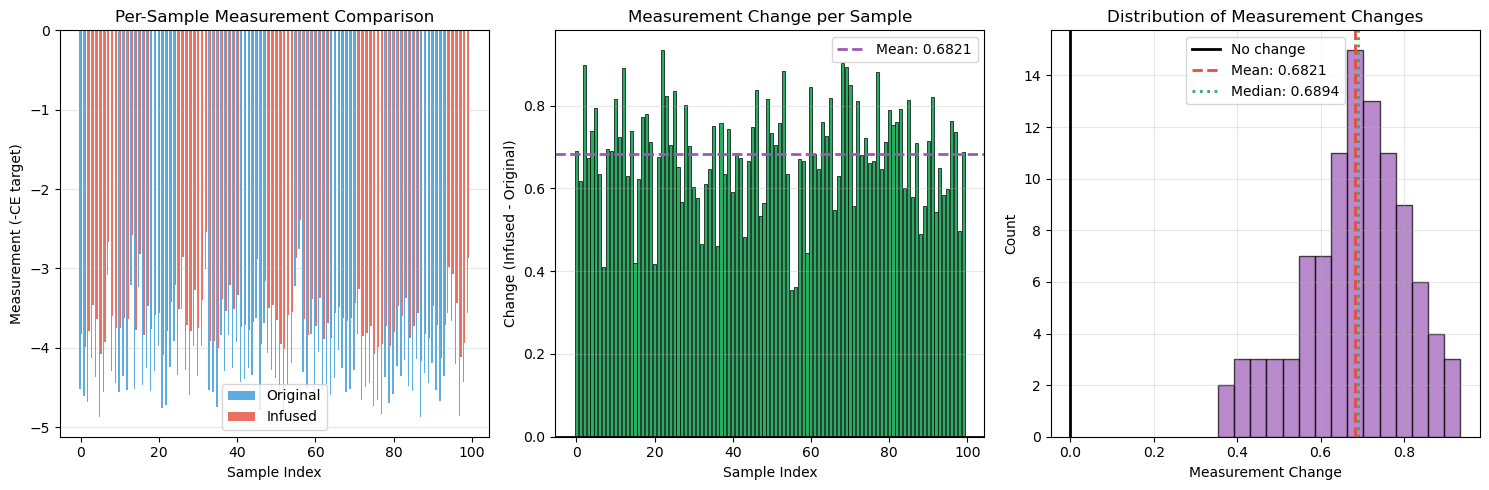


Conclusion: Mean change = +0.682074 ± 0.126270


In [24]:
# Visualization of measurement comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Side-by-side comparison per sample
ax1 = axes[0]
x_pos = np.arange(len(measurements_orig))
width = 0.35
ax1.bar(x_pos - width/2, measurements_orig, width, label='Original', color='#3498db', alpha=0.8)
ax1.bar(x_pos + width/2, measurements_inf, width, label='Infused', color='#e74c3c', alpha=0.8)
ax1.set_xlabel('Sample Index')
ax1.set_ylabel('Measurement (-CE target)')
ax1.set_title('Per-Sample Measurement Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Change per sample
ax2 = axes[1]
colors = ['#27ae60' if d > 0 else '#e74c3c' for d in measurement_diff]
ax2.bar(x_pos, measurement_diff, color=colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linewidth=2)
ax2.axhline(y=measurement_diff.mean(), color='#9b59b6', linewidth=2, linestyle='--', label=f'Mean: {measurement_diff.mean():.4f}')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Change (Infused - Original)')
ax2.set_title('Measurement Change per Sample')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Distribution of changes
ax3 = axes[2]
ax3.hist(measurement_diff, bins=15, color='#9b59b6', edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='black', linewidth=2, label='No change')
ax3.axvline(x=measurement_diff.mean(), color='#e74c3c', linewidth=2, linestyle='--', label=f'Mean: {measurement_diff.mean():.4f}')
ax3.axvline(x=np.median(measurement_diff), color='#27ae60', linewidth=2, linestyle=':', label=f'Median: {np.median(measurement_diff):.4f}')
ax3.set_xlabel('Measurement Change')
ax3.set_ylabel('Count')
ax3.set_title('Distribution of Measurement Changes')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConclusion: Mean change = {measurement_diff.mean():+.6f} ± {measurement_diff.std():.6f}")